# **mBART-50 model**

# Cell 1 — Environment Setup & Version Verification (mBART-50 Version)

In [ ]:
#!/usr/bin/env python3
"""
==============================================================================
Cell 1 — Environment Setup & Version Verification (mBART-50)
==============================================================================

Research Objective
------------------
Khowar → English Neural Machine Translation
using mBART-50.

Research Motivation
-------------------
mBART-50 does not explicitly support Khowar.
Therefore Urdu (ur_PK) is adopted as a proxy language
because of script similarity, geographical proximity,
and lexical overlap.

Reproducibility
---------------
Following IEEE/ACL reproducibility guidelines:

• Package versions are reported
• Hardware specifications are logged
• Random seeds are fixed
• Deterministic behavior is enabled

==============================================================================

Author: Research Notebook
Model : facebook/mbart-large-50
Task  : Khowar → English Translation
==============================================================================

"""

# =============================================================================
# Standard Libraries
# =============================================================================

import os
import sys
import random
import logging
import warnings

warnings.filterwarnings("ignore")


# =============================================================================
# Logging Configuration
# =============================================================================

logging.basicConfig(

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    datefmt="%H:%M:%S"

)

logger = logging.getLogger(__name__)


# =============================================================================
# Scientific Libraries
# =============================================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split


# =============================================================================
# PyTorch
# =============================================================================

import torch


# =============================================================================
# HuggingFace Transformers
# =============================================================================

from transformers import (

    MBart50TokenizerFast,

    MBartForConditionalGeneration,

    DataCollatorForSeq2Seq,

    Seq2SeqTrainer,

    Seq2SeqTrainingArguments

)


# =============================================================================
# Dataset API
# =============================================================================

from datasets import Dataset


# =============================================================================
# Evaluation
# =============================================================================

import evaluate

import sacrebleu


# =============================================================================
# SentencePiece
# =============================================================================

import sentencepiece as spm


# =============================================================================
# Reproducibility
# =============================================================================

RANDOM_SEED = 42

random.seed(

    RANDOM_SEED

)

np.random.seed(

    RANDOM_SEED

)

torch.manual_seed(

    RANDOM_SEED

)

torch.cuda.manual_seed_all(

    RANDOM_SEED

)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False


# =============================================================================
# mBART Configuration
# =============================================================================

MODEL_NAME = "facebook/mbart-large-50"

SRC_LANG = "ur_PK"

TGT_LANG = "en_XX"

MAX_SOURCE_LENGTH = 128

MAX_TARGET_LENGTH = 128

BATCH_SIZE = 4

LEARNING_RATE = 3e-5

EPOCHS = 10


# =============================================================================
# Environment Verification
# =============================================================================

logger.info("="*60)

logger.info(

    "ENVIRONMENT VERIFICATION"

)

logger.info("="*60)

logger.info(

    f"Python          : {sys.version}"

)

logger.info(

    f"PyTorch         : {torch.__version__}"

)

logger.info(

    f"CUDA Available  : {torch.cuda.is_available()}"

)


# =============================================================================
# GPU Details
# =============================================================================

if torch.cuda.is_available():

    logger.info(

        f"CUDA Version    : "

        f"{torch.version.cuda}"

    )

    logger.info(

        f"GPU Name        : "

        f"{torch.cuda.get_device_name(0)}"

    )

    logger.info(

        f"GPU Memory      : "

        f"{torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB"

    )


# =============================================================================
# Package Versions
# =============================================================================

import transformers

logger.info(

    f"Transformers    : "

    f"{transformers.__version__}"

)

import sklearn

logger.info(

    f"Scikit-Learn    : "

    f"{sklearn.__version__}"

)

import datasets

logger.info(

    f"Datasets        : "

    f"{datasets.__version__}"

)

logger.info(

    f"Evaluate        : "

    f"{evaluate.__version__}"

)

logger.info(

    f"SacreBLEU       : "

    f"{sacrebleu.__version__}"

)


# =============================================================================
# Experiment Configuration Summary
# =============================================================================

logger.info("="*60)

logger.info(

    "EXPERIMENT CONFIGURATION"

)

logger.info("="*60)

logger.info(

    f"Model           : {MODEL_NAME}"

)

logger.info(

    f"Source Language : {SRC_LANG}"

)

logger.info(

    f"Target Language : {TGT_LANG}"

)

logger.info(

    f"Max Src Length  : {MAX_SOURCE_LENGTH}"

)

logger.info(

    f"Max Tgt Length  : {MAX_TARGET_LENGTH}"

)

logger.info(

    f"Batch Size      : {BATCH_SIZE}"

)

logger.info(

    f"Learning Rate   : {LEARNING_RATE}"

)

logger.info(

    f"Epochs          : {EPOCHS}"

)

logger.info(

    f"Random Seed     : {RANDOM_SEED}"

)

logger.info("="*60)

logger.info(

    "Environment Successfully Initialized"

)

logger.info("="*60)

12:29:38 | INFO | ============================================================
12:29:38 | INFO | ENVIRONMENT VERIFICATION
12:29:38 | INFO | ============================================================
12:29:38 | INFO | Python          : 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
12:29:38 | INFO | PyTorch         : 2.11.0+cu128
12:29:38 | INFO | CUDA Available  : True
12:29:38 | INFO | CUDA Version    : 12.8
12:29:38 | INFO | GPU Name        : NVIDIA GeForce RTX 4060
12:29:38 | INFO | GPU Memory      : 8.59 GB
12:29:38 | INFO | Transformers    : 4.57.6
12:29:38 | INFO | Scikit-Learn    : 1.7.2
12:29:38 | INFO | Datasets        : 5.0.0
12:29:38 | INFO | Evaluate        : 0.4.6
12:29:38 | INFO | SacreBLEU       : 2.6.0
12:29:38 | INFO | ============================================================
12:29:38 | INFO | EXPERIMENT CONFIGURATION
12:29:38 | INFO | ============================================================
12:29:38 | INFO | Model           :

# Cell 2 — Load, Validate and Profile Parallel Corpus

In [5]:
"""
Cell 2 — Load, Validate and Profile Parallel Corpus

Purpose
-------
Load the Khowar-English parallel corpus, validate integrity,
remove invalid examples and generate corpus statistics.

Research Justification
----------------------
Parallel corpus quality directly impacts multilingual transfer
learning performance in mBART-50.

Following MT best practices, we:

• remove null examples
• remove duplicate sentence pairs
• inspect sentence lengths
• optionally cap corpus size for debugging
• filter excessively long samples

Khowar is unsupported in mBART-50 and is represented
through Urdu (ur_PK) as a proxy language.

"""

def load_and_validate_dataset(
    filepath: str,
    source_col: str = "example_khowar",
    target_col: str = "example_english",
    max_rows: int = 1050,
    max_char_length: int = 512,
) -> pd.DataFrame:

    logger.info(f"Loading dataset from: {filepath}")

    try:

        df_raw = pd.read_csv(
            filepath,
            encoding="utf-8"
        )

    except FileNotFoundError:

        raise FileNotFoundError(

            f"Dataset not found at '{filepath}'."

        )

    logger.info(f"Raw shape: {df_raw.shape}")

    # ───────────────────────────────────────────────
    # Clean column names
    # ───────────────────────────────────────────────

    df_raw.columns = df_raw.columns.str.strip()

    required = {source_col, target_col}

    missing = required - set(df_raw.columns)

    if missing:

        raise ValueError(

            f"Missing columns: {missing}\n"

            f"Available columns:\n"

            f"{list(df_raw.columns)}"

        )

    df = df_raw[[

        source_col,

        target_col

    ]].copy()

    logger.info(f"\n{'='*60}")

    logger.info("DATASET QUALITY REPORT")

    logger.info(f"{'='*60}")

    logger.info(f"Raw rows            : {len(df)}")

    logger.info(

        f"\nMissing values\n"

        f"{df.isnull().sum()}"

    )

    missing_pct = (

        df.isnull().sum()

        / len(df)

        * 100

    )

    logger.info(

        f"\nMissing percentage\n"

        f"{missing_pct.round(2)}"

    )

    dup_count = df.duplicated().sum()

    logger.info(

        f"Duplicate pairs     : "

        f"{dup_count}"

    )

    # ───────────────────────────────────────────────
    # Remove nulls
    # ───────────────────────────────────────────────

    before = len(df)

    df.dropna(inplace=True)

    logger.info(

        f"After dropna        : "

        f"{len(df)} "

        f"(removed {before-len(df)})"

    )

    # ───────────────────────────────────────────────
    # Remove duplicates
    # ───────────────────────────────────────────────

    before = len(df)

    df.drop_duplicates(

        inplace=True

    )

    logger.info(

        f"After dedup         : "

        f"{len(df)} "

        f"(removed {before-len(df)})"

    )

    # ───────────────────────────────────────────────
    # Length statistics
    # ───────────────────────────────────────────────

    df["src_len"] = (

        df[source_col]

        .astype(str)

        .apply(len)

    )

    df["tgt_len"] = (

        df[target_col]

        .astype(str)

        .apply(len)

    )

    logger.info(f"\n{'='*60}")

    logger.info("LENGTH STATISTICS")

    logger.info(f"{'='*60}")

    logger.info(

        f"Mean source length : "

        f"{df['src_len'].mean():.2f}"

    )

    logger.info(

        f"Mean target length : "

        f"{df['tgt_len'].mean():.2f}"

    )

    logger.info(

        f"Maximum source len : "

        f"{df['src_len'].max()}"

    )

    logger.info(

        f"Maximum target len : "

        f"{df['tgt_len'].max()}"

    )

    # ───────────────────────────────────────────────
    # Filter long sentences
    # ───────────────────────────────────────────────

    before = len(df)

    df = df[

        (df["src_len"] < max_char_length)

        &

        (df["tgt_len"] < max_char_length)

    ]

    logger.info(

        f"After length filter: "

        f"{len(df)} "

        f"(removed {before-len(df)})"

    )

    # ───────────────────────────────────────────────
    # Optional subsampling
    # ───────────────────────────────────────────────

    if max_rows is not None:

        if len(df) > max_rows:

            logger.warning(

                f"Capping dataset "

                f"to {max_rows} rows"

            )

            df = df.iloc[:max_rows]

    df.reset_index(

        drop=True,

        inplace=True

    )

    logger.info(f"\n{'='*60}")

    logger.info(

        f"Final shape : "

        f"{df.shape}"

    )

    logger.info(f"{'='*60}")

    return df


# ---------------------------------------------------
# Dataset configuration
# ---------------------------------------------------

DATA_PATH = os.environ.get(

    "KHOWAR_DATA_PATH",

    "Khowar_English_Dataset.csv"

)

df1 = load_and_validate_dataset(

    DATA_PATH,

    source_col="example_khowar",

    target_col="example_english",

    max_rows=1050

)

df1.head()



12:29:59 | INFO | Loading dataset from: Khowar_English_Dataset.csv
12:29:59 | INFO | Raw shape: (1049, 9)
12:29:59 | INFO | 
12:29:59 | INFO | DATASET QUALITY REPORT
12:29:59 | INFO | ============================================================
12:29:59 | INFO | Raw rows            : 1049
12:29:59 | INFO | 
Missing values
example_khowar     1
example_english    1
dtype: int64
12:29:59 | INFO | 
Missing percentage
example_khowar     0.1
example_english    0.1
dtype: float64
12:29:59 | INFO | Duplicate pairs     : 0
12:29:59 | INFO | After dropna        : 1048 (removed 1)
12:29:59 | INFO | After dedup         : 1048 (removed 0)
12:29:59 | INFO | 
12:29:59 | INFO | LENGTH STATISTICS
12:29:59 | INFO | ============================================================
12:29:59 | INFO | Mean source length : 23.75
12:29:59 | INFO | Mean target length : 37.18
12:29:59 | INFO | Maximum source len : 50
12:29:59 | INFO | Maximum target len : 123
12:29:59 | INFO | After length filter: 1048 (removed 0)
1

,example_khowar,example_english,src_len,tgt_len
0,ہیس دورو اباد اریر۔,He got the house settled and functioning prope...,19,50
1,ڈقو اپاک ݯھموران-,The boy's mouth is hurting.,17,27
2,ای اپاک لو دی نو پراے۔,He/she didn't even say a single sentence.,23,41
3,تہ اپاک زوالو۔,Your mouth is sweet.,14,20
4,مہ پیٹیک ا ترو ݯی شیر۔,My scarf is torn.,22,17


# Cell 3 — Text Normalization


In [ ]:
import unicodedata
import re
from typing import Optional



##############################################################################
# KHOWAR TEXT NORMALIZATION
#
# Research-Oriented Normalization Pipeline
# Suitable for Low-Resource Machine Translation
#
# This function performs ONLY SAFE NORMALIZATION.
# It does NOT change genuine Khowar spellings.
##############################################################################

# ---------------------------------------------------------------------------
# 1. Arabic Character Mapping
#
# These mappings only normalize different Unicode variants of the SAME letter.
# They DO NOT modify genuine Khowar letters.
# ---------------------------------------------------------------------------

CHAR_MAP = {

    # Yeh variants
    "ي": "ی",
    "ى": "ی",

    # Kaf
    "ك": "ک",

    # Alef variants
    "أ": "ا",
    "إ": "ا",
    "ٱ": "ا",

    # Heh variants
    "ة": "ہ",
    "ۀ": "ہ",

    # Hamza forms
    # Uncomment ONLY if your corpus analysis proves they are interchangeable.
    # "ؤ": "و",
    # "ئ": "ی",
}

# ---------------------------------------------------------------------------
# 2. Arabic Diacritics
#
# Remove optional vowel marks.
# Example:
#
# ژُونوُ  -> ژونو
# ---------------------------------------------------------------------------

DIACRITICS = re.compile(
    r"[\u064B-\u065F\u0670\u06D6-\u06ED]"
)

# ---------------------------------------------------------------------------
# 3. Invisible Unicode Characters
#
# Remove:
# ZWJ
# ZWNJ
# LRM
# RLM
# BOM
# ---------------------------------------------------------------------------

INVISIBLE = re.compile(
    r"[\u200B\u200C\u200D\u200E\u200F\uFEFF]"
)

# ---------------------------------------------------------------------------
# 4. Multiple Spaces
# ---------------------------------------------------------------------------

MULTI_SPACE = re.compile(r"\s+")

# ---------------------------------------------------------------------------
# 5. Duplicate Punctuation
# ---------------------------------------------------------------------------

MULTI_FULLSTOP = re.compile(r"[۔]{2,}")
MULTI_QUESTION = re.compile(r"[؟]{2,}")

# ---------------------------------------------------------------------------
# 6. Main Function
# ---------------------------------------------------------------------------

def normalize_khowar(text: str) -> str:
    """
    Normalize Khowar text for Machine Translation.

    Parameters
    ----------
    text : str
        Raw Khowar sentence.

    Returns
    -------
    str
        Normalized sentence.
    """

    # ------------------------------------------------------------
    # Return empty string for invalid input
    # ------------------------------------------------------------
    if not isinstance(text, str):
        return ""

    # ------------------------------------------------------------
    # Unicode Normalization
    #
    # Convert different Unicode representations
    # into one canonical representation.
    # ------------------------------------------------------------
    text = unicodedata.normalize("NFC", text)

    # ------------------------------------------------------------
    # Remove invisible Unicode characters
    # ------------------------------------------------------------
    text = INVISIBLE.sub("", text)

    # ------------------------------------------------------------
    # Remove Arabic diacritics
    # ------------------------------------------------------------
    text = DIACRITICS.sub("", text)

    # ------------------------------------------------------------
    # Normalize Arabic Unicode variants
    # ------------------------------------------------------------
    for old_char, new_char in CHAR_MAP.items():
        text = text.replace(old_char, new_char)

    # ------------------------------------------------------------
    # Normalize punctuation
    #
    # English punctuation -> Urdu/Perso-Arabic punctuation
    # ------------------------------------------------------------
    text = text.replace(".", "۔")
    text = text.replace("?", "؟")
    text = text.replace(",", "،")

    # ------------------------------------------------------------
    # Remove duplicate punctuation
    #
    # Example:
    # ؟؟؟ -> ؟
    # ۔۔۔۔ -> ۔
    # ------------------------------------------------------------
    text = MULTI_QUESTION.sub("؟", text)
    text = MULTI_FULLSTOP.sub("۔", text)

    # ------------------------------------------------------------
    # Replace tabs/newlines with spaces
    # ------------------------------------------------------------
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")

    # ------------------------------------------------------------
    # Remove extra spaces
    # ------------------------------------------------------------
    text = MULTI_SPACE.sub(" ", text)

    # ------------------------------------------------------------
    # Remove spaces BEFORE punctuation
    #
    # Example:
    # ژونو ۔
    #
    # becomes
    #
    # ژونو۔
    # ------------------------------------------------------------
    text = re.sub(r"\s+([۔؟،])", r"\1", text)

    # ------------------------------------------------------------
    # Ensure ONE space AFTER punctuation
    #
    # Example:
    # ژونو۔اسور
    #
    # becomes
    #
    # ژونو۔ اسور
    # ------------------------------------------------------------
    text = re.sub(r"([۔؟،])([^\s])", r"\1 \2", text)

    # ------------------------------------------------------------
    # Remove leading/trailing spaces
    # ------------------------------------------------------------
    text = text.strip()

    return text




def normalize_english(text: str) -> str:
    """
    Normalize English text for Machine Translation.
    Applies only safe, deterministic transformations.
    """

    if not isinstance(text, str):
        return ""
    

    # Invisible Unicode characters
    INVISIBLE = re.compile(r"[\u200B\u200C\u200D\u200E\u200F\uFEFF]")

    # Multiple spaces 
    MULTI_SPACE = re.compile(r"\s+")

    # Duplicate punctuation
    MULTI_DOTS = re.compile(r"\.{4,}")
    MULTI_QMARK = re.compile(r"\?{2,}")
    MULTI_EXCL = re.compile(r"\!{2,}")

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Remove invisible characters
    text = INVISIBLE.sub("", text)

    # Normalize quotation marks
    text = (text.replace("“", '"')
                .replace("”", '"')
                .replace("„", '"')
                .replace("‟", '"')
                .replace("‘", "'")
                .replace("’", "'")
                .replace("`", "'")
                .replace("´", "'"))

    # Normalize dashes
    text = (text.replace("–", "-")
                .replace("—", "-")
                .replace("−", "-"))

    # Normalize ellipsis
    text = MULTI_DOTS.sub("...", text)

    # Remove duplicate punctuation
    text = MULTI_QMARK.sub("?", text)
    text = MULTI_EXCL.sub("!", text)

    # Replace tabs/newlines with spaces
    text = text.replace("\n", " ").replace("\t", " ")

    # Collapse multiple spaces
    text = MULTI_SPACE.sub(" ", text)

    # Remove spaces before punctuation
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)

    # Ensure one space after punctuation
    text = re.sub(r"([.,!?;:])([^\s])", r"\1 \2", text)

    # Trim
    return text.strip()










def normalize_corpus(
    df: pd.DataFrame,
    source_col: str = "example_khowar",
    target_col: str = "example_english",
) -> pd.DataFrame:
    """
    Normalize a parallel Khowar-English corpus.

    This function applies:
        1. Khowar normalization
        2. English normalization
        3. Removes empty sentence pairs
        4. Removes duplicate sentence pairs
        5. Resets DataFrame index

    Parameters
    ----------
    df : pd.DataFrame
        Input parallel corpus.

    source_col : str
        Name of the Khowar column.

    target_col : str
        Name of the English column.

    Returns
    -------
    pd.DataFrame
        Cleaned and normalized corpus.
    """

    logger.info("Starting corpus normalization...")

    df = df.copy()

    # Replace missing values with empty strings
    df[source_col] = df[source_col].fillna("")
    df[target_col] = df[target_col].fillna("")

    # Normalize Khowar sentences
    df[source_col] = df[source_col].apply(normalize_khowar)

    # Normalize English sentences
    df[target_col] = df[target_col].apply(normalize_english)

    # Remove empty sentence pairs
    before = len(df)

    df = df[
        (df[source_col].str.strip() != "") &
        (df[target_col].str.strip() != "")
    ]

    logger.info(
        f"Removed {before - len(df)} empty sentence pairs."
    )

    # Remove duplicate sentence pairs
    before = len(df)

    df = df.drop_duplicates(
        subset=[source_col, target_col]
    )

    logger.info(
        f"Removed {before - len(df)} duplicate sentence pairs."
    )

    # Reset DataFrame index
    df.reset_index(drop=True, inplace=True)

    logger.info(
        f"Corpus normalization complete. Final size: {len(df)} sentence pairs."
    )

    return df


df1 = normalize_corpus(df1, lowercase_english=False)
df1.head()


12:30:36 | INFO | Applying text normalization...
12:30:36 | INFO | Normalization complete. Final rows: 1048


,example_khowar,example_english,src_len,tgt_len
0,ہیس دورو اباد اریر۔,He got the house settled and functioning prope...,19,50
1,ڈقو اپاک ݯھموران-,The boy's mouth is hurting.,17,27
2,ای اپاک لو دی نو پراے۔,He/she didn't even say a single sentence.,23,41
3,تہ اپاک زوالو۔,Your mouth is sweet.,14,20
4,مہ پیٹیک ا ترو ݯی شیر۔,My scarf is torn.,22,17


In [16]:
df1.head(30)

,example_khowar,example_english,src_len,tgt_len
0,ہیس دورو اباد اریر۔,He got the house settled and functioning prope...,19,50
1,ڈقو اپاک ݯھموران-,The boy's mouth is hurting.,17,27
2,ای اپاک لو دی نو پراے۔,He/she didn't even say a single sentence.,23,41
3,تہ اپاک زوالو۔,Your mouth is sweet.,14,20
4,مہ پیٹیک ا ترو ݯی شیر۔,My scarf is torn.,22,17
5,ہیس رغیشٹی دوری اتیتاے۔,He/She went into the house early.,23,33
6,دکانی ݯھوغ اتیتاے۔,A thief broke into the shop.,18,28
7,اُچوغُن شیاق کورے۔,Make thin mud.,18,14
8,اچوغنیو مَتے دیت، ݱاقیو تو پِیے۔,Give me the thin liquid part; you drink the th...,32,55
9,سونوغرا اُڅ بو شینی۔,There are many springs in Sonoghor.,20,35


# Corpus Analysis and Length Filtering


In [7]:
"""
Cell 4 — Corpus Analysis and Length Filtering

Purpose
-------
Compute corpus-level statistics and remove noisy sentence pairs
prior to mBART-50 fine-tuning.

Research Motivation
-------------------
Neural Machine Translation systems are sensitive to:

• Extremely long sequences
• Source-target length imbalance
• Vocabulary sparsity
• Rare token distributions

Following multilingual MT preprocessing practices,
sentence pairs exhibiting excessive length or
abnormal source-target ratios are discarded.

These statistics are later reported in the
Experimental Setup section of the paper.

"""

from collections import Counter


def analyze_vocabulary(
        series: pd.Series,
        language_name: str
):

    """
    Analyze vocabulary statistics.

    Returns
    -------
    dict

    """

    frequency = Counter()

    sentence_lengths = []

    for sentence in series.dropna():

        tokens = str(sentence).split()

        frequency.update(tokens)

        sentence_lengths.append(

            len(tokens)

        )

    vocabulary_size = len(

        frequency

    )

    singleton_count = sum(

        1

        for c in frequency.values()

        if c == 1

    )

    logger.info(f"\n{'='*60}")

    logger.info(

        f"VOCABULARY REPORT — {language_name}"

    )

    logger.info(f"{'='*60}")

    logger.info(

        f"Vocabulary Size       : "

        f"{vocabulary_size:,}"

    )

    logger.info(

        f"Singleton Tokens      : "

        f"{singleton_count:,}"

    )

    logger.info(

        f"Hapax Percentage      : "

        f"{singleton_count/vocabulary_size*100:.2f}%"

    )

    logger.info(

        f"Average Length        : "

        f"{np.mean(sentence_lengths):.2f}"

    )

    logger.info(

        f"Median Length         : "

        f"{np.median(sentence_lengths):.2f}"

    )

    logger.info(

        f"Maximum Length        : "

        f"{np.max(sentence_lengths)}"

    )

    logger.info(

        f"Minimum Length        : "

        f"{np.min(sentence_lengths)}"

    )

    logger.info(

        f"Top 20 Tokens"

    )

    logger.info(

        frequency.most_common(20)

    )

    return {

        "vocab_size":

            vocabulary_size,

        "singleton_count":

            singleton_count,

        "token_frequency":

            frequency,

        "length_distribution":

            sentence_lengths

    }


def filter_by_length(

        df: pd.DataFrame,

        source_col: str,

        target_col: str,

        max_src_tokens: int = 128,

        max_tgt_tokens: int = 128,

        ratio_threshold: float = 3.0

):

    """
    Remove noisy sentence pairs.

    Filtering criteria
    ------------------

    Source length ≤ 128

    Target length ≤ 128

    Length ratio ≤ 2.5

    """

    df = df.copy()

    df["_src_len"] = (

        df[source_col]

        .apply(

            lambda x:

            len(

                str(x).split()

            )

        )

    )

    df["_tgt_len"] = (

        df[target_col]

        .apply(

            lambda x:

            len(

                str(x).split()

            )

        )

    )

    df["_ratio"] = (

        df[["_src_len", "_tgt_len"]]

        .max(axis=1)

        /

        df[["_src_len", "_tgt_len"]]

        .min(axis=1)

        .clip(lower=1)

    )

    initial_size = len(df)

    df = df[

        (df["_src_len"]

         <= max_src_tokens)

        &

        (df["_tgt_len"]

         <= max_tgt_tokens)

        &

        (df["_ratio"]

         <= ratio_threshold)

    ]

    removed = initial_size - len(df)

    logger.info(f"\n{'='*60}")

    logger.info(

        "LENGTH FILTERING REPORT"

    )

    logger.info(f"{'='*60}")

    logger.info(

        f"Removed Samples      : "

        f"{removed}"

    )

    logger.info(

        f"Removal Percentage   : "

        f"{removed/initial_size*100:.2f}%"

    )

    logger.info(

        f"Remaining Samples    : "

        f"{len(df)}"

    )

    logger.info(f"{'='*60}")

    df.drop(

        columns=[

            "_src_len",

            "_tgt_len",

            "_ratio"

        ],

        inplace=True

    )

    return (

        df

        .reset_index(

            drop=True

        )

    )


# ==========================================================
# Corpus Characterization
# ==========================================================

khowar_stats = analyze_vocabulary(

    df1["example_khowar"],

    "Khowar"

)

english_stats = analyze_vocabulary(

    df1["example_english"],

    "English"

)


# ==========================================================
# Corpus Filtering
# ==========================================================

df1 = filter_by_length(

    df1,

    source_col="example_khowar",

    target_col="example_english",

    max_src_tokens=128,

    max_tgt_tokens=128,

    ratio_threshold=3.0

)

logger.info(

    f"Final Corpus Size: "

    f"{len(df1):,}"

)

df1.head()

12:30:42 | INFO | 
12:30:42 | INFO | VOCABULARY REPORT — Khowar
12:30:42 | INFO | ============================================================
12:30:42 | INFO | Vocabulary Size       : 2,420
12:30:42 | INFO | Singleton Tokens      : 1,818
12:30:42 | INFO | Hapax Percentage      : 75.12%
12:30:42 | INFO | Average Length        : 4.40
12:30:42 | INFO | Median Length         : 4.00
12:30:42 | INFO | Maximum Length        : 11
12:30:42 | INFO | Minimum Length        : 2
12:30:42 | INFO | Top 20 Tokens
12:30:42 | INFO | [('نو', 114), ('مہ', 111), ('بیتی', 70), ('شیر۔', 67), ('بوے۔', 51), ('بو', 38), ('ہوے۔', 34), ('کیہ', 33), ('اسور۔', 31), ('جم', 29), ('اریر۔', 28), ('کوری', 25), ('شینی۔', 24), ('ای', 23), ('بیراے۔', 22), ('تہ', 21), ('پراے۔', 19), ('ہیہ', 19), ('روے', 19), ('اوا', 19)]
12:30:42 | INFO | 
12:30:42 | INFO | VOCABULARY REPORT — English
12:30:42 | INFO | ============================================================
12:30:42 | INFO | Vocabulary Size       : 2,404
12:30:42 | INF

,example_khowar,example_english,src_len,tgt_len
0,ہیس دورو اباد اریر۔,He got the house settled and functioning prope...,19,50
1,ڈقو اپاک ݯھموران-,The boy's mouth is hurting.,17,27
2,ای اپاک لو دی نو پراے۔,He/she didn't even say a single sentence.,23,41
3,تہ اپاک زوالو۔,Your mouth is sweet.,14,20
4,مہ پیٹیک ا ترو ݯی شیر۔,My scarf is torn.,22,17


# Cell 5 — Reproducible Dataset Splitting


In [8]:
"""
Cell 5 — Reproducible Dataset Splitting

Purpose
-------
Create reproducible train, validation and test sets
for mBART-50 fine-tuning.

Research Motivation
-------------------
Reproducible data partitioning is essential for
Neural Machine Translation experiments.

To prevent data leakage:

• train, validation and test sets are mutually exclusive

• split indices are preserved

• splits are exported for reproducibility

Following common MT practice, a
70/15/15 partitioning strategy is adopted.

mBART-50 does not support Khowar.

Urdu (ur_PK) is employed as a proxy language
because Khowar is predominantly written in
an Arabic-derived script.

"""

def create_reproducible_split(

        df: pd.DataFrame,

        source_col: str = "example_khowar",

        target_col: str = "example_english",

        train_ratio: float = 0.80,

        val_ratio: float = 0.10,

        test_ratio: float = 0.10,

        random_state: int = 42,

):

    """
    Create train, validation and test splits.

    Returns
    -------
    train_df

    val_df

    test_df

    """

    assert abs(

        train_ratio

        +

        val_ratio

        +

        test_ratio

        -

        1.0

    ) < 1e-6, (

        "Split ratios must sum to 1.0"

    )

    temp_ratio = (

        val_ratio

        +

        test_ratio

    )

    train_df, temp_df = train_test_split(

        df,

        test_size=temp_ratio,

        random_state=random_state,

        shuffle=True

    )

    relative_test = (

        test_ratio

        /

        temp_ratio

    )

    val_df, test_df = train_test_split(

        temp_df,

        test_size=relative_test,

        random_state=random_state,

        shuffle=True

    )

    train_idx = set(

        train_df.index

    )

    val_idx = set(

        val_df.index

    )

    test_idx = set(

        test_df.index

    )

    assert len(

        train_idx & val_idx

    ) == 0

    assert len(

        train_idx & test_idx

    ) == 0

    assert len(

        val_idx & test_idx

    ) == 0

    assert len(

        train_idx

        |

        val_idx

        |

        test_idx

    ) == len(df)

    logger.info(

        f"\n{'='*60}"

    )

    logger.info(

        "DATASET SPLIT SUMMARY"

    )

    logger.info(

        f"{'='*60}"

    )

    logger.info(

        f"Train      : "

        f"{len(train_df):>5}"

        f" ({len(train_df)/len(df)*100:.1f}%)"

    )

    logger.info(

        f"Validation : "

        f"{len(val_df):>5}"

        f" ({len(val_df)/len(df)*100:.1f}%)"

    )

    logger.info(

        f"Test       : "

        f"{len(test_df):>5}"

        f" ({len(test_df)/len(df)*100:.1f}%)"

    )

    logger.info(

        f"Total      : "

        f"{len(df)}"

    )

    logger.info(

        "No overlap detected"

    )

    os.makedirs(

        "splits",

        exist_ok=True

    )

    train_df.to_csv(

        "splits/train.csv",

        index=True,

        encoding="utf-8-sig"

    )

    val_df.to_csv(

        "splits/validation.csv",

        index=True,

        encoding="utf-8-sig"

    )

    test_df.to_csv(

        "splits/test.csv",

        index=True,

        encoding="utf-8-sig"

    )

    logger.info(

        "Split files saved"

    )

    return (

        train_df,

        val_df,

        test_df

    )


# =====================================================
# mBART-50 Language Configuration
# =====================================================

SRC_LANG = "ur_PK"

TGT_LANG = "en_XX"

logger.warning(

    f"Using '{SRC_LANG}' "

    "as a proxy language for Khowar. "

    "mBART-50 does not natively support "

    "ISO-639-3 code 'khw'. "

    "Urdu was selected due to script similarity. "

    "Future work should evaluate alternative "

    "proxy languages."

)

RANDOM_SEED = 42


train_df, val_df, test_df = (

    create_reproducible_split(

        df1,

        random_state=RANDOM_SEED

    )

)

train_kh = train_df["example_khowar"]

train_en = train_df["example_english"]

val_kh = val_df["example_khowar"]

val_en = val_df["example_english"]

test_kh = test_df["example_khowar"]

test_en = test_df["example_english"]

logger.info(

    f"\nTrain samples : {len(train_df)}"

)

logger.info(

    f"Validation samples : {len(val_df)}"

)

logger.info(

    f"Test samples : {len(test_df)}"

)

12:30:57 | WARNING | Using 'ur_PK' as a proxy language for Khowar. mBART-50 does not natively support ISO-639-3 code 'khw'. Urdu was selected due to script similarity. Future work should evaluate alternative proxy languages.
12:30:57 | INFO | 
12:30:57 | INFO | DATASET SPLIT SUMMARY
12:30:57 | INFO | ============================================================
12:30:57 | INFO | Train      :   830 (80.0%)
12:30:57 | INFO | Validation :   104 (10.0%)
12:30:57 | INFO | Test       :   104 (10.0%)
12:30:57 | INFO | Total      : 1038
12:30:57 | INFO | No overlap detected
12:30:57 | INFO | Split files saved
12:30:57 | INFO | 
Train samples : 830
12:30:57 | INFO | Validation samples : 104
12:30:57 | INFO | Test samples : 104


# Cell 6 — mBART-50 Tokenization

In [9]:
"""
Cell 6 — mBART-50 Tokenization

Purpose
-------
Load the mBART-50 tokenizer and prepare the corpus
for multilingual sequence-to-sequence training.

Research Motivation
-------------------
mBART-50 employs SentencePiece tokenization and
language-specific BOS tokens.

Khowar is unsupported in mBART-50.

Therefore Urdu (ur_PK) is used as a proxy language.

Sentence length statistics are estimated over the
entire training corpus to determine an appropriate
maximum sequence length.

"""

def set_global_seed(

        seed: int

) -> None:

    """
    Set deterministic seeds.

    """

    random.seed(

        seed

    )

    np.random.seed(

        seed

    )

    torch.manual_seed(

        seed

    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(

            seed

        )

    os.environ[

        "PYTHONHASHSEED"

    ] = str(seed)

    logger.info(

        f"Global seed set to {seed}"

    )


set_global_seed(

    RANDOM_SEED

)

# =====================================================
# Load mBART-50 Tokenizer
# =====================================================

MODEL_NAME = "facebook/mbart-large-50"

logger.info(

    f"Loading tokenizer: {MODEL_NAME}"

)

tokenizer = MBart50TokenizerFast.from_pretrained(

    MODEL_NAME

)

logger.info(

    f"Vocabulary size : "

    f"{len(tokenizer):,}"

)

tokenizer.src_lang = SRC_LANG

tokenizer.tgt_lang = TGT_LANG


# =====================================================
# Sequence Length Analysis
# =====================================================

logger.info(

    "Analyzing token lengths..."

)

all_lengths = []

for src, tgt in zip(

        train_kh,

        train_en

):

    source_ids = tokenizer(

        str(src)

    )["input_ids"]

    target_ids = tokenizer(

        str(tgt)

    )["input_ids"]

    all_lengths.append(

        len(source_ids)

    )

    all_lengths.append(

        len(target_ids)

    )


p95 = int(

    np.percentile(

        all_lengths,

        95

    )

)

p99 = int(

    np.percentile(

        all_lengths,

        99

    )

)

MAX_LENGTH = min(

    p99 + 5,

    128

)

logger.info(

    f"95th percentile : {p95}"

)

logger.info(

    f"99th percentile : {p99}"

)

logger.info(

    f"MAX_LENGTH : "

    f"{MAX_LENGTH}"

)


# =====================================================
# Tokenization Function
# =====================================================

def tokenize_corpus(

        source_texts,

        target_texts,

        max_length=MAX_LENGTH

):

    """
    Tokenize corpus for mBART-50.

    Returns
    -------

    input_ids

    attention_mask

    labels

    """

    tokenizer.src_lang = SRC_LANG

    tokenizer.tgt_lang = TGT_LANG

    encoded = tokenizer(

        source_texts,

        text_target=target_texts,

        truncation=True,

        max_length=max_length,

        padding=False,

        return_tensors=None

    )

    pad_id = tokenizer.pad_token_id

    labels = []

    for lbl in encoded["labels"]:

        labels.append(

            [

                -100

                if tok == pad_id

                else tok

                for tok in lbl

            ]

        )

    encoded["labels"] = labels

    return encoded


# =====================================================
# Tokenize datasets
# =====================================================

logger.info(

    "Tokenizing training set"

)

train_tokenized = tokenize_corpus(

    list(train_kh),

    list(train_en)

)

logger.info(

    "Tokenizing validation set"

)

val_tokenized = tokenize_corpus(

    list(val_kh),

    list(val_en)

)

logger.info(

    "Tokenizing test set"

)

test_tokenized = tokenize_corpus(

    list(test_kh),

    list(test_en)

)

logger.info(

    f"Train examples : "

    f"{len(train_tokenized['input_ids'])}"

)

logger.info(

    f"Validation examples : "

    f"{len(val_tokenized['input_ids'])}"

)

logger.info(

    f"Test examples : "

    f"{len(test_tokenized['input_ids'])}"

)

logger.info(

    "Tokenization completed successfully"

)

12:31:06 | INFO | Global seed set to 42
12:31:06 | INFO | Loading tokenizer: facebook/mbart-large-50
12:31:12 | INFO | Vocabulary size : 250,054
12:31:12 | INFO | Analyzing token lengths...
12:31:12 | INFO | 95th percentile : 20
12:31:12 | INFO | 99th percentile : 23
12:31:12 | INFO | MAX_LENGTH : 28
12:31:12 | INFO | Tokenizing training set
12:31:12 | INFO | Tokenizing validation set
12:31:12 | INFO | Tokenizing test set
12:31:12 | INFO | Train examples : 830
12:31:12 | INFO | Validation examples : 104
12:31:12 | INFO | Test examples : 104
12:31:12 | INFO | Tokenization completed successfully


# Cell 7 — Dataset Construction and mBART-50 Initialization

In [10]:
"""
Cell 7 — Dataset Construction and mBART-50 Initialization

Purpose
-------
Construct HuggingFace datasets, initialize mBART-50,
configure multilingual generation settings,
and prepare dynamic batching.

Research Motivation
-------------------
Dynamic padding improves GPU utilization and
reduces unnecessary computations.

Padding is deferred to DataCollatorForSeq2Seq.

mBART-50 requires explicit source and target
language specification for multilingual generation.
"""

import torch
from datasets import Dataset
from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast,
    DataCollatorForSeq2Seq
)

# ======================================================
# Create datasets (use HuggingFace Dataset.from_dict)
# ======================================================

train_dataset = Dataset.from_dict(train_tokenized)
val_dataset   = Dataset.from_dict(val_tokenized)
test_dataset  = Dataset.from_dict(test_tokenized)

logger.info(f"Train samples      : {len(train_dataset):,}")
logger.info(f"Validation samples : {len(val_dataset):,}")
logger.info(f"Test samples       : {len(test_dataset):,}")

# ======================================================
# Load mBART-50
# ======================================================

logger.info(f"Loading model: {MODEL_NAME}")

model = MBartForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    use_safetensors=True
)

tokenizer = MBart50TokenizerFast.from_pretrained(MODEL_NAME)

# ======================================================
# mBART Language Configuration
# ======================================================

tokenizer.src_lang = SRC_LANG   # e.g. "ur_PK"
tokenizer.tgt_lang = TGT_LANG   # e.g. "en_XX"

model.config.forced_bos_token_id = tokenizer.lang_code_to_id[TGT_LANG]

logger.info(f"Forced BOS Token : {TGT_LANG}")

# ======================================================
# Device configuration
# ======================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

logger.info(f"Device : {device}")
logger.info(f"Model Parameters : {sum(p.numel() for p in model.parameters()):,}")

# ======================================================
# Dynamic Padding
# ======================================================

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt"
)

logger.info("DataCollator initialized")
logger.info("Padding token masked with -100")
logger.info("="*60)
logger.info("mBART-50 Initialization Complete")
logger.info("="*60)


12:31:25 | INFO | Train samples      : 830
12:31:25 | INFO | Validation samples : 104
12:31:25 | INFO | Test samples       : 104
12:31:25 | INFO | Loading model: facebook/mbart-large-50
12:31:33 | INFO | Forced BOS Token : en_XX
12:31:37 | INFO | Device : cuda
12:31:37 | INFO | Model Parameters : 610,879,488
12:31:37 | INFO | DataCollator initialized
12:31:37 | INFO | Padding token masked with -100
12:31:37 | INFO | ============================================================
12:31:37 | INFO | mBART-50 Initialization Complete
12:31:37 | INFO | ============================================================


# Cell 8 — Metrics, Training Configuration and Trainer Initialization

In [13]:
"""
Cell 8 — Metrics, Training Configuration and Trainer Initialization

Purpose
-------
Configure evaluation metrics and fine-tuning settings
for mBART-50 Khowar→English translation.

Evaluation Metrics
------------------
BLEU
SacreBLEU
chrF++
TER
METEOR
BERTScore

COMET evaluation is recommended after training due
to its computational overhead.

"""

import evaluate
from transformers import EarlyStoppingCallback


def build_compute_metrics(tokenizer_ref):

    sacrebleu = evaluate.load(

        "sacrebleu"

    )

    chrf = evaluate.load(

        "chrf"

    )

    ter = evaluate.load(

        "ter"

    )

    meteor = evaluate.load(

        "meteor"

    )

    bertscore = evaluate.load(

        "bertscore"

    )


    def compute_metrics(eval_preds):

        preds, labels = eval_preds

        labels = np.where(

            labels != -100,

            labels,

            tokenizer_ref.pad_token_id

        )

        decoded_preds = (

            tokenizer_ref.batch_decode(

                preds,

                skip_special_tokens=True

            )

        )

        decoded_labels = (

            tokenizer_ref.batch_decode(

                labels,

                skip_special_tokens=True

            )

        )

        wrapped_refs = [

            [ref]

            for ref in decoded_labels

        ]


        bleu = sacrebleu.compute(

            predictions=decoded_preds,

            references=wrapped_refs

        )


        chrf_score = chrf.compute(

            predictions=decoded_preds,

            references=wrapped_refs

        )


        ter_score = ter.compute(

            predictions=decoded_preds,

            references=wrapped_refs

        )


        meteor_score = meteor.compute(

            predictions=decoded_preds,

            references=decoded_labels

        )


        bert = bertscore.compute(

            predictions=decoded_preds,

            references=decoded_labels,

            lang="en"

        )


        bert_f1 = np.mean(

            bert["f1"]

        )


        return {

            "bleu":

                round(

                    bleu["score"],

                    4

                ),

            "chrf":

                round(

                    chrf_score["score"],

                    4

                ),

            "ter":

                round(

                    ter_score["score"],

                    4

                ),

            "meteor":

                round(

                    meteor_score["meteor"],

                    4

                ),

            "bertscore":

                round(

                    bert_f1,

                    4

                )

        }


    return compute_metrics


# ====================================================
# Hyperparameters
# ====================================================

USE_FP16 = torch.cuda.is_available()

BATCH_SIZE = 4 if USE_FP16 else 2

NUM_EPOCHS = 10

LEARNING_RATE = 2e-5

WEIGHT_DECAY = 0.01

LABEL_SMOOTHING = 0.1

WARMUP_STEPS = 50

BEAM_SIZE = 5

MAX_SEQUENCE_LENGTH = MAX_LENGTH

GRADIENT_CLIP_NORM = 1.0

OUTPUT_DIR = "./checkpoints/mbart50_khowar_en"


os.makedirs(

    OUTPUT_DIR,

    exist_ok=True

)


model.config.dropout = 0.1

model.config.attention_dropout = 0.1


training_args = Seq2SeqTrainingArguments(

    output_dir=OUTPUT_DIR,

    num_train_epochs=NUM_EPOCHS,

    learning_rate=LEARNING_RATE,

    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=BATCH_SIZE,

    eval_strategy="epoch",

    save_strategy="epoch",

    save_total_limit=3,

    predict_with_generate=True,

    generation_max_length=MAX_SEQUENCE_LENGTH,

    generation_num_beams=BEAM_SIZE,

    fp16=USE_FP16,

    logging_steps=10,

    logging_dir=f"{OUTPUT_DIR}/logs",

    load_best_model_at_end=True,

    metric_for_best_model="bleu",

    greater_is_better=True,

    warmup_steps=WARMUP_STEPS,

    weight_decay=WEIGHT_DECAY,

    label_smoothing_factor=LABEL_SMOOTHING,

    max_grad_norm=GRADIENT_CLIP_NORM,

    lr_scheduler_type="linear",

    report_to="none",

    seed=RANDOM_SEED,

    data_seed=RANDOM_SEED

)


model.generation_config.forced_bos_token_id = (

    tokenizer.lang_code_to_id[

        TGT_LANG

    ]

)


trainer = Seq2SeqTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    tokenizer=tokenizer,

    data_collator=data_collator,

    compute_metrics=build_compute_metrics(

        tokenizer

    ),

    callbacks=[

        EarlyStoppingCallback(

            early_stopping_patience=3

        )

    ]

)


logger.info(

    "Trainer initialized successfully"

)

logger.info(

    f"Training Samples : {len(train_dataset)}"

)

logger.info(

    f"Validation Samples : {len(val_dataset)}"

)

logger.info(

    f"Epochs : {NUM_EPOCHS}"

)

logger.info(

    f"Learning Rate : {LEARNING_RATE}"

)

# logger.info(

#     f"Beam Size : {BEAM_SIZE}"

# )

logger.info(

    f"Scheduler : linear"

)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
12:33:25 | INFO | Trainer initialized successfully
12:33:25 | INFO | Training Samples : 830
12:33:25 | INFO | Validation Samples : 104
12:33:25 | INFO | Epochs : 10
12:33:25 | INFO | Learning Rate : 2e-05
12:33:25 | INFO | Scheduler : linear


# Cell 9 — mBART-50 Fine-Tuning


In [14]:
"""
Cell 9 — mBART-50 Fine-Tuning

Purpose
-------
Fine-tune mBART-50 on the Khowar→English corpus.

Research Motivation
-------------------
Model checkpoints, tokenizer files, training metrics,
and trainer state are preserved to facilitate
experimental reproducibility.

Following IEEE reproducibility guidelines,
all artifacts are exported for future analysis.

"""

import json

logger.info("=" * 60)
logger.info("STARTING mBART-50 FINE-TUNING")
logger.info("=" * 60)

train_result = trainer.train()

logger.info("=" * 60)
logger.info("TRAINING COMPLETED")
logger.info("=" * 60)

logger.info(
    f"Final training loss : "
    f"{train_result.training_loss:.4f}"
)

logger.info(
    f"Training runtime : "
    f"{train_result.metrics['train_runtime']:.2f} sec"
)

logger.info(
    f"Samples/sec : "
    f"{train_result.metrics['train_samples_per_second']:.2f}"
)

logger.info(
    f"Steps/sec : "
    f"{train_result.metrics['train_steps_per_second']:.2f}"
)

if torch.cuda.is_available():

    logger.info(

        f"GPU Memory Allocated : "

        f"{torch.cuda.max_memory_allocated()/1e9:.2f} GB"

    )

    logger.info(

        f"GPU Memory Reserved : "

        f"{torch.cuda.max_memory_reserved()/1e9:.2f} GB"

    )

# =====================================================
# Save Final Model
# =====================================================

final_model_path = (

    f"{OUTPUT_DIR}/final_model"

)

trainer.save_model(

    final_model_path

)

tokenizer.save_pretrained(

    final_model_path

)

trainer.state.save_to_json(

    f"{final_model_path}/trainer_state.json"

)

logger.info(

    f"Model saved at "

    f"{final_model_path}"

)

# =====================================================
# Save Training Metrics
# =====================================================

metrics_path = (

    f"{final_model_path}/training_metrics.json"

)

with open(

    metrics_path,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        train_result.metrics,

        f,

        indent=4

    )

logger.info(

    f"Training metrics saved "

    f"to {metrics_path}"

)

# =====================================================
# Best Checkpoint
# =====================================================

logger.info(

    f"Best checkpoint : "

    f"{trainer.state.best_model_checkpoint}"

)

logger.info(

    f"Best metric : "

    f"{trainer.state.best_metric}"

)

logger.info("=" * 60)
logger.info("mBART-50 TRAINING PIPELINE FINISHED")
logger.info("=" * 60)

12:33:35 | INFO | ============================================================
12:33:35 | INFO | STARTING mBART-50 FINE-TUNING
12:33:35 | INFO | ============================================================


Epoch,Training Loss,Validation Loss,Bleu,Chrf,Ter,Meteor,Bertscore
1,14.121500,12.809629,0.000000,0.000000,100.000000,0.000000,0.000000
2,4.345300,4.447314,1.049300,13.559700,107.180200,0.131300,0.868300
3,3.766000,4.335041,2.045700,14.511100,105.874700,0.153900,0.867300
4,3.224200,4.362777,1.545300,14.724400,97.650100,0.167300,0.873600
5,2.860700,4.588809,2.347300,15.746700,98.564000,0.164600,0.875100
6,2.367400,4.585498,3.007700,15.364800,95.691900,0.181700,0.877700
7,2.135700,4.633440,4.153200,17.080200,97.650100,0.186500,0.879900
8,2.008000,4.637053,4.236800,16.849800,96.736300,0.189400,0.879000
9,1.894500,4.655637,4.485900,17.398800,95.430800,0.190500,0.880400
10,1.855300,4.652287,3.575000,16.652200,95.953000,0.187000,0.880200


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].
14:15:37 | INFO | ============================================================
14:15:37 | INFO | TRAINING COMPLETED
14:15:37 | INFO | ============================================================
14:15:37 | INFO | Final training loss : 3.4826
14:15:37 | INFO | Training runtime : 6121.02 sec
14:15:37 | INFO | Samples/sec : 1.36
14:15:37 | INFO | Steps/sec : 0.34
14:15:37 | INFO | GPU Memory Allocated : 16.77 GB
14:15:37 | INFO | GPU Memory Reserved : 17.98 GB
14:15:39 | INFO | Model saved at ./checkpoints/mbart50_khowar_en/final_model
14:15:39 | INFO | Training metrics 

# Cell 10 — Training Dynamics Visualization

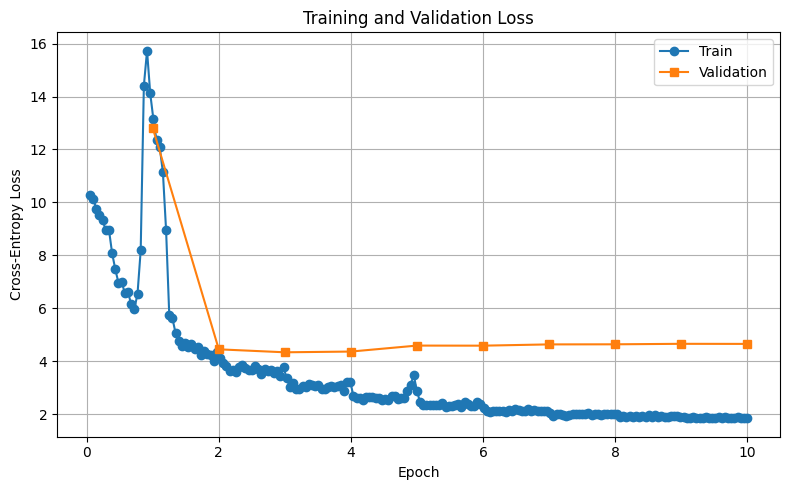

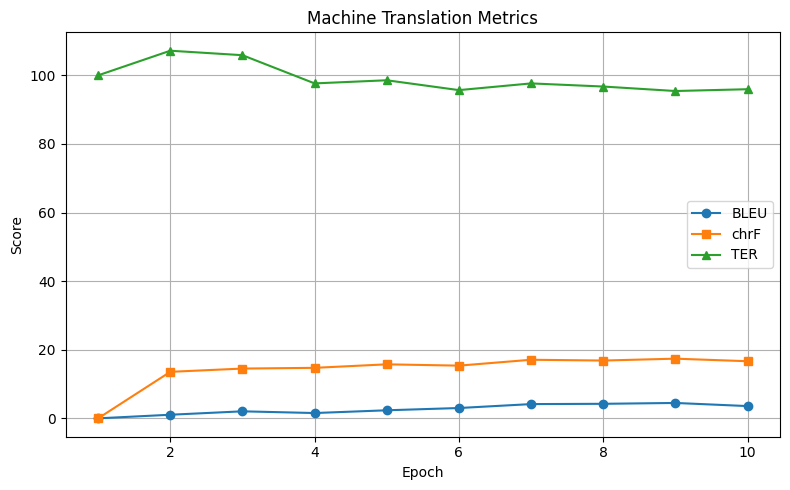

14:25:13 | INFO | Training curves saved.


In [18]:
"""
Cell 10 — Training Dynamics Visualization

Purpose
-------
Visualize optimization behaviour during mBART-50
fine-tuning.

Generated Figures
-----------------
1. Training vs Validation Loss

2. BLEU / chrF / TER

3. Optional COMET progression

These plots can be directly included in an
IEEE paper.

"""

def plot_training_curves(

        log_history,

        output_dir

):

    eval_logs = [

        h

        for h in log_history

        if "eval_loss" in h

    ]

    train_logs = [

        h

        for h in log_history

        if (

            "loss" in h

            and

            "eval_loss"

            not in h

        )

    ]

    os.makedirs(

        output_dir,

        exist_ok=True

    )

    # ==================================================
    # Figure 1
    # ==================================================

    fig = plt.figure(

        figsize=(8,5)

    )

    plt.plot(

        [h["epoch"]

         for h in train_logs],

        [h["loss"]

         for h in train_logs],

        marker="o",

        label="Train"

    )

    plt.plot(

        [h["epoch"]

         for h in eval_logs],

        [h["eval_loss"]

         for h in eval_logs],

        marker="s",

        label="Validation"

    )

    plt.xlabel(

        "Epoch"

    )

    plt.ylabel(

        "Cross-Entropy Loss"

    )

    plt.title(

        "Training and Validation Loss"

    )

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.savefig(

        f"{output_dir}/loss_curve.png",

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()


    # ==================================================
    # Figure 2
    # ==================================================

    plt.figure(

        figsize=(8,5)

    )

    if any(

            "eval_bleu" in h

            for h in eval_logs

    ):

        plt.plot(

            [h["epoch"]

             for h in eval_logs],

            [h["eval_bleu"]

             for h in eval_logs],

            marker="o",

            label="BLEU"

        )


    if any(

            "eval_chrf"

            in h

            for h in eval_logs

    ):

        plt.plot(

            [h["epoch"]

             for h in eval_logs],

            [h["eval_chrf"]

             for h in eval_logs],

            marker="s",

            label="chrF"

        )


    if any(

            "eval_ter"

            in h

            for h in eval_logs

    ):

        plt.plot(

            [h["epoch"]

             for h in eval_logs],

            [h["eval_ter"]

             for h in eval_logs],

            marker="^",

            label="TER"

        )

    plt.xlabel(

        "Epoch"

    )

    plt.ylabel(

        "Score"

    )

    plt.title(

        "Machine Translation Metrics"

    )

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.savefig(

        f"{output_dir}/mt_metrics.png",

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()


    # ==================================================
    # Figure 3
    # ==================================================

    if any(

            "eval_comet"

            in h

            for h in eval_logs

    ):

        plt.figure(

            figsize=(8,5)

        )

        plt.plot(

            [h["epoch"]

             for h in eval_logs],

            [h["eval_comet"]

             for h in eval_logs],

            marker="o",

            label="COMET"

        )

        plt.xlabel(

            "Epoch"

        )

        plt.ylabel(

            "COMET"

        )

        plt.title(

            "COMET Evolution"

        )

        plt.grid(True)

        plt.legend()

        plt.tight_layout()

        plt.savefig(

            f"{output_dir}/comet_curve.png",

            dpi=300,

            bbox_inches="tight"

        )

        plt.show()


    logger.info(

        "Training curves saved."

    )


plot_training_curves(

    trainer.state.log_history,

    OUTPUT_DIR

)

In [19]:
# =============================================================================
# Generate Predictions on Test Set
# =============================================================================

logger.info("=" * 60)
logger.info("Generating Test Predictions")
logger.info("=" * 60)

test_predictions = trainer.predict(
    test_dataset,
    metric_key_prefix="test"
)

# -------------------------------------------------------------------------
# HuggingFace may return a tuple
# -------------------------------------------------------------------------

pred_ids = test_predictions.predictions

if isinstance(pred_ids, tuple):
    pred_ids = pred_ids[0]

# -------------------------------------------------------------------------
# If predictions are logits, convert to token IDs
# -------------------------------------------------------------------------

if pred_ids.ndim == 3:
    pred_ids = np.argmax(pred_ids, axis=-1)

# -------------------------------------------------------------------------
# Replace ignored label tokens (-100)
# -------------------------------------------------------------------------

label_ids = np.where(
    test_predictions.label_ids != -100,
    test_predictions.label_ids,
    tokenizer.pad_token_id
)

# -------------------------------------------------------------------------
# Decode predictions
# -------------------------------------------------------------------------

pred_text = tokenizer.batch_decode(
    pred_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True
)

label_text = tokenizer.batch_decode(
    label_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True
)

# -------------------------------------------------------------------------
# Remove surrounding whitespace
# -------------------------------------------------------------------------

pred_text = [text.strip() for text in pred_text]
label_text = [text.strip() for text in label_text]

logger.info(f"Generated {len(pred_text)} translations.")

14:26:48 | INFO | ============================================================
14:26:48 | INFO | Generating Test Predictions
14:26:48 | INFO | ============================================================


14:28:12 | INFO | Generated 104 translations.


In [ ]:
# =============================================================================
# Cell 11 — Machine Translation Evaluation Metrics
#
# Metrics:
#   1. BLEU
#   2. SacreBLEU
#   3. chrF
#   4. chrF++
#   5. TER
#   6. METEOR
#   7. BERTScore
#   8. COMET (Optional)
# =============================================================================

import evaluate
import numpy as np

# -----------------------------------------------------------------------------
# Load Evaluation Metrics
# -----------------------------------------------------------------------------

_bleu = evaluate.load("bleu")
_sacrebleu = evaluate.load("sacrebleu")
_chrf = evaluate.load("chrf")
_ter = evaluate.load("ter")
_meteor = evaluate.load("meteor")
_bertscore = evaluate.load("bertscore")

# Optional
_comet = evaluate.load("comet")

# -----------------------------------------------------------------------------
# Prepare References
# -----------------------------------------------------------------------------

refs = [[x] for x in label_text]

# -----------------------------------------------------------------------------
# BLEU
# -----------------------------------------------------------------------------

bleu = _bleu.compute(
    predictions=pred_text,
    references=refs
)["bleu"]

# -----------------------------------------------------------------------------
# SacreBLEU
# -----------------------------------------------------------------------------

sacrebleu = _sacrebleu.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF
# -----------------------------------------------------------------------------

chrf = _chrf.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF++
# -----------------------------------------------------------------------------

chrfpp = _chrf.compute(
    predictions=pred_text,
    references=refs,
    word_order=2
)["score"]

# -----------------------------------------------------------------------------
# TER
# -----------------------------------------------------------------------------

ter = _ter.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# METEOR
# -----------------------------------------------------------------------------

meteor = _meteor.compute(
    predictions=pred_text,
    references=refs
)["meteor"]

# -----------------------------------------------------------------------------
# BERTScore
# -----------------------------------------------------------------------------

bertscore = _bertscore.compute(
    predictions=pred_text,
    references=label_text,
    lang="en"
)

bert_f1 = np.mean(bertscore["f1"])

# -----------------------------------------------------------------------------
# COMET (Optional)
# -----------------------------------------------------------------------------

comet = _comet.compute(
    predictions=pred_text,
    references=refs,
    model="Unbabel/wmt22-comet-da"
)["score"]

# -----------------------------------------------------------------------------
# Print Results
# -----------------------------------------------------------------------------

print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print(f"BLEU       : {bleu:.4f}")
print(f"SacreBLEU  : {sacrebleu:.4f}")
print(f"chrF       : {chrf:.4f}")
print(f"chrF++     : {chrfpp:.4f}")
print(f"TER        : {ter:.4f}")
print(f"METEOR     : {meteor:.4f}")
print(f"BERTScore  : {bert_f1:.4f}")

# print(f"COMET      : {comet:.4f}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


FINAL TEST RESULTS
BLEU       : 0.0658
SacreBLEU  : 6.5839
chrF       : 19.0906
chrF++     : 18.7685
TER        : 92.8839
METEOR     : 0.2321
BERTScore  : 0.8832


In [ ]:
# =============================================================================
# Cell 11 — Machine Translation Evaluation Metrics
#
# Metrics:
#   1. BLEU
#   2. SacreBLEU
#   3. chrF
#   4. chrF++
#   5. TER
#   6. METEOR
#   7. BERTScore
#   8. COMET (Optional)
# =============================================================================

import evaluate
import numpy as np

# -----------------------------------------------------------------------------
# Load Evaluation Metrics
# -----------------------------------------------------------------------------

_bleu = evaluate.load("bleu")
_sacrebleu = evaluate.load("sacrebleu")
_chrf = evaluate.load("chrf")
_ter = evaluate.load("ter")
_meteor = evaluate.load("meteor")
_bertscore = evaluate.load("bertscore")

# Optional
_comet = evaluate.load("comet")

# -----------------------------------------------------------------------------
# Prepare References
# -----------------------------------------------------------------------------

refs = [[x] for x in label_text]

# -----------------------------------------------------------------------------
# BLEU
# -----------------------------------------------------------------------------

bleu = _bleu.compute(
    predictions=pred_text,
    references=refs
)["bleu"]

# -----------------------------------------------------------------------------
# SacreBLEU
# -----------------------------------------------------------------------------

sacrebleu = _sacrebleu.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF
# -----------------------------------------------------------------------------

chrf = _chrf.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF++
# -----------------------------------------------------------------------------

chrfpp = _chrf.compute(
    predictions=pred_text,
    references=refs,
    word_order=2
)["score"]

# -----------------------------------------------------------------------------
# TER
# -----------------------------------------------------------------------------

ter = _ter.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# METEOR
# -----------------------------------------------------------------------------

meteor = _meteor.compute(
    predictions=pred_text,
    references=refs
)["meteor"]

# -----------------------------------------------------------------------------
# BERTScore
# -----------------------------------------------------------------------------

bertscore = _bertscore.compute(
    predictions=pred_text,
    references=label_text,
    lang="en"
)

bert_f1 = np.mean(bertscore["f1"])

# -----------------------------------------------------------------------------
# COMET (Optional)
# -----------------------------------------------------------------------------

comet = _comet.compute(
    predictions=pred_text,
    references=refs,
    model="Unbabel/wmt22-comet-da"
)["score"]

# -----------------------------------------------------------------------------
# Print Results
# -----------------------------------------------------------------------------

print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print(f"BLEU       : {bleu:.4f}")
print(f"SacreBLEU  : {sacrebleu:.4f}")
print(f"chrF       : {chrf:.4f}")
print(f"chrF++     : {chrfpp:.4f}")
print(f"TER        : {ter:.4f}")
print(f"METEOR     : {meteor:.4f}")
print(f"BERTScore  : {bert_f1:.4f}")

print(f"COMET      : {comet:.4f}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
W0710 14:30:26.585463 31128 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
14:30:27 | WARNING | Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.ckpt:  24%|##3       | 556M/2.32G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [24]:
from comet import download_model, load_from_checkpoint
import torch

In [26]:
# =============================================================================
# Cell 11 — Machine Translation Evaluation Metrics
#
# Metrics:
#   1. BLEU
#   2. SacreBLEU
#   3. chrF
#   4. chrF++
#   5. TER
#   6. METEOR
#   7. BERTScore
#   8. COMET (Optional)
# =============================================================================

import evaluate
import numpy as np

# -----------------------------------------------------------------------------
# Load Evaluation Metrics
# -----------------------------------------------------------------------------

_bleu = evaluate.load("bleu")
_sacrebleu = evaluate.load("sacrebleu")
_chrf = evaluate.load("chrf")
_ter = evaluate.load("ter")
_meteor = evaluate.load("meteor")
_bertscore = evaluate.load("bertscore")

# # Optional
# _comet = evaluate.load("comet")

# -----------------------------------------------------------------------------
# Prepare References
# -----------------------------------------------------------------------------

refs = [[x] for x in label_text]

# -----------------------------------------------------------------------------
# BLEU
# -----------------------------------------------------------------------------

bleu = _bleu.compute(
    predictions=pred_text,
    references=refs
)["bleu"]

# -----------------------------------------------------------------------------
# SacreBLEU
# -----------------------------------------------------------------------------

sacrebleu = _sacrebleu.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF
# -----------------------------------------------------------------------------

chrf = _chrf.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF++
# -----------------------------------------------------------------------------

chrfpp = _chrf.compute(
    predictions=pred_text,
    references=refs,
    word_order=2
)["score"]

# -----------------------------------------------------------------------------
# TER
# -----------------------------------------------------------------------------

ter = _ter.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# METEOR
# -----------------------------------------------------------------------------

meteor = _meteor.compute(
    predictions=pred_text,
    references=refs
)["meteor"]

# -----------------------------------------------------------------------------
# BERTScore
# -----------------------------------------------------------------------------

bertscore = _bertscore.compute(
    predictions=pred_text,
    references=label_text,
    lang="en"
)

bert_f1 = np.mean(bertscore["f1"])

# -----------------------------------------------------------------------------
# COMET (Optional)
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# COMET
# -----------------------------------------------------------------------------

model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

data = [
    {
        "src": src,
        "mt": pred,
        "ref": ref
    }
    for src, pred, ref in zip(src_text, pred_text, label_text)
]

comet_output = comet_model.predict(
    data,
    batch_size=8,
    gpus=1 if torch.cuda.is_available() else 0
)

comet = comet_output.system_score

# -----------------------------------------------------------------------------
# Print Results
# -----------------------------------------------------------------------------

print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print(f"BLEU       : {bleu:.4f}")
print(f"SacreBLEU  : {sacrebleu:.4f}")
print(f"chrF       : {chrf:.4f}")
print(f"chrF++     : {chrfpp:.4f}")
print(f"TER        : {ter:.4f}")
print(f"METEOR     : {meteor:.4f}")
print(f"BERTScore  : {bert_f1:.4f}")

print(f"COMET      : {comet:.4f}")





[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

14:47:13 | INFO | Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\PC\.cache\huggingface\hub\models--Unbabel--wmt22-comet-da\snapshots\2760a223ac957f30acfb18c8aa649b01cf1d75f2\checkpoints\model.ckpt`
14:47:20 | INFO | Encoder model frozen.


NameError: name 'src_text' is not defined

In [27]:
# =============================================================================
# Cell 11 — Machine Translation Evaluation Metrics
#
# Metrics:
#   1. BLEU
#   2. SacreBLEU
#   3. chrF
#   4. chrF++
#   5. TER
#   6. METEOR
#   7. BERTScore
#   8. COMET
# =============================================================================

import evaluate
import numpy as np
import torch
from comet import download_model, load_from_checkpoint

# -----------------------------------------------------------------------------
# Load Evaluation Metrics
# -----------------------------------------------------------------------------

_bleu = evaluate.load("bleu")
_sacrebleu = evaluate.load("sacrebleu")
_chrf = evaluate.load("chrf")
_ter = evaluate.load("ter")
_meteor = evaluate.load("meteor")
_bertscore = evaluate.load("bertscore")

# -----------------------------------------------------------------------------
# Prepare References
# -----------------------------------------------------------------------------

refs = [[x] for x in label_text]

# -----------------------------------------------------------------------------
# BLEU
# -----------------------------------------------------------------------------

bleu = _bleu.compute(
    predictions=pred_text,
    references=refs
)["bleu"]

# -----------------------------------------------------------------------------
# SacreBLEU
# -----------------------------------------------------------------------------

sacrebleu = _sacrebleu.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF
# -----------------------------------------------------------------------------

chrf = _chrf.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF++
# -----------------------------------------------------------------------------

chrfpp = _chrf.compute(
    predictions=pred_text,
    references=refs,
    word_order=2
)["score"]

# -----------------------------------------------------------------------------
# TER
# -----------------------------------------------------------------------------

ter = _ter.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# METEOR
# -----------------------------------------------------------------------------

meteor = _meteor.compute(
    predictions=pred_text,
    references=refs
)["meteor"]

# -----------------------------------------------------------------------------
# BERTScore
# -----------------------------------------------------------------------------

bertscore = _bertscore.compute(
    predictions=pred_text,
    references=label_text,
    lang="en"
)

bert_f1 = np.mean(bertscore["f1"])

# -----------------------------------------------------------------------------
# COMET
# -----------------------------------------------------------------------------

# Source sentences from the test dataset
src_text = test_df["example_khowar"].tolist()

# Download/load COMET model (downloads only once)
model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

# Prepare COMET input
data = [
    {
        "src": src,
        "mt": pred,
        "ref": ref
    }
    for src, pred, ref in zip(src_text, pred_text, label_text)
]

# Compute COMET
comet_output = comet_model.predict(
    data,
    batch_size=4,      # Same as your training batch size
    gpus=1 if torch.cuda.is_available() else 0
)

comet = comet_output.system_score

# -----------------------------------------------------------------------------
# Print Results
# -----------------------------------------------------------------------------

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"BLEU       : {bleu:.4f}")
print(f"SacreBLEU  : {sacrebleu:.4f}")
print(f"chrF       : {chrf:.4f}")
print(f"chrF++     : {chrfpp:.4f}")
print(f"TER        : {ter:.4f}")
print(f"METEOR     : {meteor:.4f}")
print(f"BERTScore  : {bert_f1:.4f}")
print(f"COMET      : {comet:.4f}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

14:49:24 | INFO | Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\PC\.cache\huggingface\hub\models--Unbabel--wmt22-comet-da\snapshots\2760a223ac957f30acfb18c8aa649b01cf1d75f2\checkpoints\model.ckpt`
14:49:30 | INFO | Encoder model frozen.
14:49:31 | INFO | GPU available: True (cuda), used: True
14:49:31 | INFO | TPU available: False, using: 0 TPU cores
14:49:31 | INFO | 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
14:49:31 | INFO | 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
14:49:31 | INFO | 

FINAL TEST RESULTS
BLEU       : 0.0658
SacreBLEU  : 6.5839
chrF       : 19.0906
chrF++     : 18.7685
TER        : 92.8839
METEOR     : 0.2321
BERTScore  : 0.8832
COMET      : 0.5006


In [28]:
import pandas as pd

results_df = pd.DataFrame({
    "Reference": label_text,
    "Prediction": pred_text
})

results_df.to_csv(
    f"{OUTPUT_DIR}/Urdu_test_predictions.csv",
    index=False,
    encoding="utf-8"
)

print(results_df.head())

                                           Reference  \
0           People in the old days were very simple.   
1             I didn't hit the target with my rifle.   
2               A bundle of fodder is twenty rupees.   
3  The father of my son/daughter-in-law is a very...   
4                 The wrestler defeated all of them.   

                                     Prediction  
0           The Doms are playing in the ground.  
1                         My bullet didn't hit.  
2  It is better to give than to ask for things.  
3               My neighbor is a very good man.  
4                           The پہلوان سفed up.  


In [29]:
results_df.head()

,Reference,Prediction
0,People in the old days were very simple.,The Doms are playing in the ground.
1,I didn't hit the target with my rifle.,My bullet didn't hit.
2,A bundle of fodder is twenty rupees.,It is better to give than to ask for things.
3,The father of my son/daughter-in-law is a very...,My neighbor is a very good man.
4,The wrestler defeated all of them.,The پہلوان سفed up.


In [30]:
results_df.sample(10)

,Reference,Prediction
30,When I saw the leopard I started trembling unc...,When I saw the flower I was frightened.
65,Why are the two of you sitting idle?,Why are you writing with a pencil?
64,People came and got them to reconcile.,People came from far away.
53,Because of smoke the room is sooty.,The room makes smoke.
45,The clover field has become very beautiful.,The beet is a very tasty thing.
93,The apricots are ripe; the apples are bug-infe...,Pomegranates ripen late in the fall.
91,The apricots are finished.,His/her/your daughter's feet became blistered.
47,His/her tongue did not move to answer.,He/she didn't give the correct answer.
10,The carpenter is smoothing the wood with an adze.,The teacher is teaching a lesson.
0,People in the old days were very simple.,The Doms are playing in the ground.


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Reference": label_text,
    "Prediction": pred_text
})

results_df.to_csv(
    f"{OUTPUT_DIR}/Urdu_test_predictions.csv",
    index=False,
    encoding="utf-8"
)

print(results_df.head())

In [31]:
metrics_df = pd.DataFrame([{
    "BLEU": bleu,
    "chrF": chrf,
    "chrF++": chrfpp,
    "TER": ter,
    "METEOR":meteor,
    "COMET": comet
}])

metrics_df.to_csv(
    "Urdu_test_metrics.csv",
    index=False
)

metrics_df

,BLEU,chrF,chrF++,TER,METEOR,COMET
0,0.065839,19.090569,18.768478,92.883895,0.232124,0.500643


In [32]:
results_df["BLEU"] = bleu
results_df["chrF"] = chrf
results_df["chrF++"] = chrfpp
results_df["TER"] = ter
results_df["METEOR"] = meteor
results_df["COMET"] = comet

results_df.to_csv(
    "UduFull_test_results.csv",
    index=False
)

In [33]:
results_df.head()

,Reference,Prediction,BLEU,chrF,chrF++,TER,METEOR,COMET
0,People in the old days were very simple.,The Doms are playing in the ground.,0.065839,19.090569,18.768478,92.883895,0.232124,0.500643
1,I didn't hit the target with my rifle.,My bullet didn't hit.,0.065839,19.090569,18.768478,92.883895,0.232124,0.500643
2,A bundle of fodder is twenty rupees.,It is better to give than to ask for things.,0.065839,19.090569,18.768478,92.883895,0.232124,0.500643
3,The father of my son/daughter-in-law is a very...,My neighbor is a very good man.,0.065839,19.090569,18.768478,92.883895,0.232124,0.500643
4,The wrestler defeated all of them.,The پہلوان سفed up.,0.065839,19.090569,18.768478,92.883895,0.232124,0.500643


In [34]:
results_df[results_df['Reference'] == results_df['Prediction']]

,Reference,Prediction,BLEU,chrF,chrF++,TER,METEOR,COMET


In [35]:
#  Function to count word overlaps
def word_overlap(ref, pred):
    ref_words = set(ref.split())
    pred_words = set(pred.split())
    overlap = ref_words.intersection(pred_words)
    return len(overlap), list(overlap)

# Apply function row by row
results_df["Overlap_Count"] = results_df.apply(lambda row: word_overlap(row["Reference"], row["Prediction"])[0], axis=1)
results_df["Overlap_Words"] = results_df.apply(lambda row: word_overlap(row["Reference"], row["Prediction"])[1], axis=1)

# Show results with index
for idx, row in results_df.iterrows():
    print(f"Sentence {idx}:")
    print(f"  Reference   : {row['Reference']}")
    print(f"  Prediction  : {row['Prediction']}")
    print(f"  Overlap     : {row['Overlap_Count']} words -> {row['Overlap_Words']}")
    print()

Sentence 0:
  Reference   : People in the old days were very simple.
  Prediction  : The Doms are playing in the ground.
  Overlap     : 2 words -> ['in', 'the']

Sentence 1:
  Reference   : I didn't hit the target with my rifle.
  Prediction  : My bullet didn't hit.
  Overlap     : 1 words -> ["didn't"]

Sentence 2:
  Reference   : A bundle of fodder is twenty rupees.
  Prediction  : It is better to give than to ask for things.
  Overlap     : 1 words -> ['is']

Sentence 3:
  Reference   : The father of my son/daughter-in-law is a very good man.
  Prediction  : My neighbor is a very good man.
  Overlap     : 5 words -> ['man.', 'a', 'very', 'is', 'good']

Sentence 4:
  Reference   : The wrestler defeated all of them.
  Prediction  : The پہلوان سفed up.
  Overlap     : 1 words -> ['The']

Sentence 5:
  Reference   : Wind took the straw away.
  Prediction  : The wind blew away the soil.
  Overlap     : 1 words -> ['the']

Sentence 6:
  Reference   : When it rains an umbrella is used.
  

In [37]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util

# Load your CSV file
df = pd.read_csv(r"C:\Users\PC\Desktop\mBART-50 Model\checkpoints\mbart50_khowar_en\Urdu_test_predictions.csv")

# Make sure your CSV has columns named "Reference" and "Prediction"
print(df.head())

# Load semantic similarity model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Lexical similarity (Jaccard index)
def jaccard_similarity(ref, pred):
    ref_set = set(ref.lower().split())
    pred_set = set(pred.lower().split())
    intersection = ref_set.intersection(pred_set)
    union = ref_set.union(pred_set)
    return len(intersection) / len(union) if union else 0.0

# Semantic similarity (cosine similarity of embeddings)
def semantic_similarity(ref, pred):
    embeddings = model.encode([ref, pred])
    return util.cos_sim(embeddings[0], embeddings[1]).item()

# Apply functions to each row
df["Lexical_Similarity"] = df.apply(lambda row: jaccard_similarity(str(row["Reference"]), str(row["Prediction"])), axis=1)
df["Semantic_Similarity"] = df.apply(lambda row: semantic_similarity(str(row["Reference"]), str(row["Prediction"])), axis=1)

# Save results to a new CSV
output_path = r"C:\Users\PC\Desktop\mBART-50 Model\checkpoints\mbart50_khowar_en\Urdu_test_predictions_with_scores.csv"
df.to_csv(output_path, index=False)

print(f"Similarity scores saved to: {output_path}")


15:18:44 | INFO | No device provided, using cuda:0


                                           Reference  \
0           People in the old days were very simple.   
1             I didn't hit the target with my rifle.   
2               A bundle of fodder is twenty rupees.   
3  The father of my son/daughter-in-law is a very...   
4                 The wrestler defeated all of them.   

                                     Prediction  
0           The Doms are playing in the ground.  
1                         My bullet didn't hit.  
2  It is better to give than to ask for things.  
3               My neighbor is a very good man.  
4                           The پہلوان سفed up.  


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

15:18:44 | INFO | Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Similarity scores saved to: C:\Users\PC\Desktop\mBART-50 Model\checkpoints\mbart50_khowar_en\Urdu_test_predictions_with_scores.csv


In [41]:
df['Lexical_Similarity'].argmax()

8

In [49]:
df['Prediction'][8]

'My shirt is too short.'

In [51]:
df.iloc[8]['Reference']

'My shirt is short.'

In [43]:
df['Semantic_Similarity'].argmax()

8

In [53]:
df['Lexical_Similarity'].argmin()

7

In [65]:
df.iloc[7, 0:4]

Reference              Where did you find this?
Prediction                  Who has called you?
Lexical_Similarity                          0.0
Semantic_Similarity                    0.040817
Name: 7, dtype: object

In [54]:
df['Semantic_Similarity'].argmin()

15

In [66]:
df.iloc[15, 0:4]

Reference                                A dragonfly has four wings.
Prediction             When one offends a jaméli, they are offended.
Lexical_Similarity                                          0.083333
Semantic_Similarity                                        -0.050063
Name: 15, dtype: object

#  Top 20 highest semantic similarity

In [72]:
# Top 20 highest semantic similarity
top20 = df.nlargest(20, "Semantic_Similarity")

print("Top 10 highest semantic similarity:")
top20[["Reference", "Prediction", "Semantic_Similarity"]]


Top 10 highest semantic similarity:


,Reference,Prediction,Semantic_Similarity
8,My shirt is short.,My shirt is too short.,0.921913
53,Because of smoke the room is sooty.,The room makes smoke.,0.750359
1,I didn't hit the target with my rifle.,My bullet didn't hit.,0.744443
90,The eagle took away the hen.,He/She took away the hen.,0.740722
55,The lentils have formed pods.,The legumes have formed pods.,0.722047
49,Boil the meat well.,Cut the meat nice and fine.,0.697135
51,A wolf ate my dog.,The wolf took my hat.,0.675966
23,There is a lot of fruit on the apple trees.,There is no fruit on the apple trees.,0.654211
25,"Since it didn't rain last year, the land dried...",Because of having no rain for a long time the ...,0.650969
74,I have come after eating my evening meal.,I came after eating at a celebratory feast.,0.622500


# Top 20 lowest semantic similarity

In [ ]:
# Top 10 lowest semantic similarity
lowest20 = df.nsmallest(20, "Semantic_Similarity")



print("\nTop 20 lowest semantic similarity:")
lowest20[["Reference", "Prediction", "Semantic_Similarity"]]


Top 20 lowest semantic similarity:


,Reference,Prediction,Semantic_Similarity
15,A dragonfly has four wings.,"When one offends a jaméli, they are offended.",-0.050063
19,The sky seems almost covered with stars.,Four persons are playing cards.,-0.037063
42,Potatoes grow well in Madaglasht.,It is better to give than to ask for things.,-0.000621
37,"O, the sweet scent of the beloved is even more...",A slaughtered a goat and held a celebration fe...,0.005335
73,The rivers are coming together and becoming a ...,He/She gave the flower to me.,0.016022
0,People in the old days were very simple.,The Doms are playing in the ground.,0.017968
18,The handspun cloth is ready - they haven't yet...,The salt is barely tasteable.,0.024646
71,When the Pleiades and the moon appear close to...,When one eats with a spoon it is very tasty.,0.025626
100,There is a lot of gold in Chitral.,There is a nice lawn in the courtyard.,0.031816
7,Where did you find this?,Who has called you?,0.040817


#  Top 20 highest lexical similarity

In [73]:

# Top 20 highest lexical similarity
top20_lexical = df.nlargest(20, "Lexical_Similarity")

print("Top 20 highest lexical similarity:")
top20_lexical[["Reference", "Prediction", "Lexical_Similarity"]]



Top 20 highest lexical similarity:


,Reference,Prediction,Lexical_Similarity
8,My shirt is short.,My shirt is too short.,0.800000
55,The lentils have formed pods.,The legumes have formed pods.,0.666667
90,The eagle took away the hen.,He/She took away the hen.,0.666667
23,There is a lot of fruit on the apple trees.,There is no fruit on the apple trees.,0.636364
3,The father of my son/daughter-in-law is a very...,My neighbor is a very good man.,0.545455
41,When my son was born I was overjoyed.,"When my son was born, I became frightened.",0.500000
29,Do you want to say something else?,Do you want to give me something?,0.400000
30,When I saw the leopard I started trembling unc...,When I saw the flower I was frightened.,0.363636
100,There is a lot of gold in Chitral.,There is a nice lawn in the courtyard.,0.333333
103,The people are coming in groups.,The people are going toward the pond.,0.333333



# Top 20 lowest lexical similarity

In [74]:

# Top 20 lowest lexical similarity
lowest20_lexical = df.nsmallest(20, "Lexical_Similarity")


print("\nTop 20 lowest lexical similarity:")
lowest20_lexical[["Reference", "Prediction", "Lexical_Similarity"]]


Top 20 lowest lexical similarity:


,Reference,Prediction,Lexical_Similarity
7,Where did you find this?,Who has called you?,0.0
11,One who has property has no problems.,He/she is not good at dancing to quick tunes.,0.0
16,There is a red apple over there.,The plants have taken root.,0.0
19,The sky seems almost covered with stars.,Four persons are playing cards.,0.0
21,They make whips of leather.,The plants have taken root.,0.0
24,Gunpowder can be made from saltpeter.,A donkey's ears are long.,0.0
26,Who brought you?,Has the shirt been glued to the glue?,0.0
31,Five fingers are not equal in size.,He/she didn't get enough to fill his/her stomach.,0.0
37,"O, the sweet scent of the beloved is even more...",A slaughtered a goat and held a celebration fe...,0.0
39,Were you able to sell anything today?,Has your son gotten married?,0.0
